# Per-algorithm policy validation — 4 CLRS algorithms

**Goal.** Validate that each realization policy actually does
what it advertises *for each CLRS algorithm we have a trace
for*. The right question is not "which policy is best?" but
"which policy fits this algorithm's transition style?".

For each algorithm we:

1. State a **hypothesis** about which policy fits, and why.
2. Run **all four policies** through the same trace.
3. Show per-transition metrics side-by-side.
4. Report a **verdict** against pre-stated pass criteria.

Algorithms cover four very different paradigms:

| # | Algorithm                          | Paradigm                                          |
|---|------------------------------------|---------------------------------------------------|
| 1 | Red-Black insert + delete          | Pointer tree with rotations                       |
| 2 | Disjoint-Set Forest                | Forest with path compression — edges-only mutation |
| 3 | Dijkstra's algorithm               | Fixed graph with evolving attributes              |
| 4 | Max-Heap insert + extract          | Array-backed implicit binary tree                 |

All policies must satisfy the layout spec —
`constraint_adherence` is checked as a guard rail, not a metric
for ranking.

### Closest prior work

**Diehl & Görg (GD 2002), *"Graphs, they are changing — dynamic
graph drawing for a sequence of graphs"*** is the closest
antecedent to this harness. They introduce *foresighted
layout* for incremental graph change and frame the problem as
an explicit **change-stability tradeoff**: a layout policy
that fully preserves prior positions cannot also accommodate
structural change, and vice versa. The four policies in this
evaluation map onto their tradeoff axis:

- `stability` ≡ maximally foresighted (reuse prior positions
  as solver seeds whenever possible).
- `change_emphasis` ≡ a deliberate move toward the change
  end of Diehl & Görg's axis: pin stable nodes, jitter
  changed ones.
- `ignore_history` ≡ the change-pole: treat each frame as
  independent.
- `random_positioning` ≡ off the axis (a baseline that
  destroys both stability and any meaningful change signal).

The contribution we're adding on top of Diehl & Görg:
(a) we run their tradeoff inside a *constraint-based* layout
(spytial-core's WebCola integration with declarative spec
constraints), where prior work has been mostly force-directed
or Sugiyama-hierarchical; (b) we add the **two-level
change/stable split** as a finer-grained reading of which
nodes the policy is supposed to be moving; (c) we evaluate
on CLRS algorithm traces rather than synthetic graph series.

See §References for Misue et al. 1995 (mental-map metrics),
Friedrich & Eades 2001 (smoothness), and the empirical
pushback (Archambault et al. 2011).

---

### Setup


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('results/aggregate.csv')
ok = df[~df['solver_failure']].copy()
print(f'Loaded {len(df)} rows, {len(ok)} after dropping solver failures.')

POLICY_ORDER = ['stability', 'change_emphasis', 'ignore_history', 'random_positioning']
POLICY_COLOR = {
    'stability': '#1f77b4',
    'change_emphasis': '#ff7f0e',
    'ignore_history': '#7f7f7f',
    'random_positioning': '#d62728',
}

adherence_check = ok.groupby('policy')['constraint_adherence'].agg(['mean', 'min'])
print('\nConstraint adherence (must be ~1 for every policy):')
print(adherence_check)

print('\nAlgorithms in this sweep:')
for a in sorted(ok['algorithm'].unique()):
    n = len(ok[ok['algorithm'] == a])
    print(f'  {a}: {n} (algo, policy, seed, transition) rows')


Loaded 296 rows, 296 after dropping solver failures.

Constraint adherence (must be ~1 for every policy):
                    mean  min
policy                       
change_emphasis     1.00    1
ignore_history      1.00    1
random_positioning  1.00    1
stability           1.00    1

Algorithms in this sweep:
  dijkstra-shortest-paths: 40 (algo, policy, seed, transition) rows
  dsu-makeset+union: 96 (algo, policy, seed, transition) rows
  heap-insert+extract: 96 (algo, policy, seed, transition) rows
  rbtree-insert+delete: 64 (algo, policy, seed, transition) rows


## What each metric measures

Every metric below compares two consecutive frames and asks a
different question. The full definitions live in
`spytial-core/src/evaluation/consistency-metrics.ts`; this is
the plain-English version. Citations (full bibliography in
§References at the end of this notebook):

- The three squared-error consistency metrics are from Penlloy
  (PLATEAU 2025) and Liang et al. (TOSEM 2026 §2.6.1, §3.4).
- The two-level split is the *change_emphasis*-style
  difference detection from Diehl & Görg (GD 2002) and
  Misue et al. (JVLC 1995).
- The salience-AUC formulation is constructed for this thesis;
  it's a rank-based reading of the changed-vs-stable
  displacement-ratio metric the proposal calls for.

### Whole-frame metrics

**`positional`** — *did the persistent layout stay put?*
For every atom that exists in **both** frames, sum
`Δx² + Δy²`. Units: pixels squared. `0` = every persisting
atom is at the exact same coordinates; tens of thousands =
atoms genuinely moved. This is the headline "preserve
continuity" metric.

**`relative`** — *did the edges keep the same shape?* Sum
`‖(curr_target − curr_source) − (prev_target − prev_source)‖²`
over edges that persist. Catches rotations and reflections
that `positional` misses (a node can have low `positional`
while its outgoing edges all flipped direction).

**`pairwise_distance`** — *did the gestalt-shape survive?*
For every pair of persisting atoms, take
`(curr_dist(i,j) − prev_dist(i,j))²` and sum. Invariant to
translation and rotation — only cares whether the layout
*as a whole* still looks the same. Units: px⁴ (because
distance is already squared from the px² scale).

**`constraint_adherence`** — *did the spec actually hold?*
Fraction of layout constraints (orientation, alignment,
etc.) satisfied within tolerance after the solver ran. In
`[0, 1]`. We want this at `1.0` always — it's a guard rail,
not a metric to optimize.

**`runtime_ms`** — solver runtime per transition. Cost-of-
policy context for every other claim.

### The two-level split

Every persisting atom is classified into one of two buckets,
**independent of policy**. From
`classifyChangeEmphasisChangedSet` in spytial-core:

- **Changed-context** = the atom's neighborhood changed
  between frames (it has a new neighbor, lost a neighbor,
  or one of its incident edges has a different identity).
- **Stable-context** = same neighbors, same edges as before.

**`changed_count` / `stable_count`** — sizes of the two
subsets. Tells you whether a transition is *local* (small
changed set, big stable set) or *wholesale* (most or all
atoms flipped).

**`changed_mean_drift` / `stable_mean_drift`** — average
pixel distance moved per atom in each subset. Plain
averages, easy to read. Units: pixels. The *ratio*
`changed / stable` is the eyeball check: 5.0 means changed
atoms moved 5× as far as stable atoms.

**`changed_positional`, `stable_positional`,
`changed_pairwise_distance`, `stable_pairwise_distance`** —
the whole-frame metrics, restricted to one subset. Lets you
write "stable subset moved < X px², changed subset moved
> Y px²" claims directly.

### `changed_vs_stable_auc` — the salience score

The metric that needs the most unpacking. It's a rank-based
score in `[0, 1]`.

**Plain definition:** Pick a random changed-context atom and
a random stable-context atom. What's the probability that
the changed one moved farther than the stable one?

**Computation** — count wins over every pair:

```
wins = 0
for changed in changed_atoms:
    for stable in stable_atoms:
        if changed.drift  > stable.drift:    wins += 1
        if changed.drift == stable.drift:    wins += 0.5
auc = wins / (len(changed_atoms) * len(stable_atoms))
```

**Reading the number:**

| AUC  | Meaning                                                                       |
| ---- | ----------------------------------------------------------------------------- |
| 1.0  | Every changed atom moved more than every stable atom. Perfect salience.       |
| 0.7  | Strong tendency: a viewer's eye will track the change correctly most of the time. |
| 0.5  | No signal. Drift is unrelated to whether the atom's context changed.          |
| 0.0  | Inverted: stable atoms consistently moved more than changed atoms. Wrong way. |

**Why this metric.** It's *rank-based*, so it doesn't care
about absolute pixel scale — only whether changed atoms are
"ranked higher" by drift than stable atoms. That makes it
comparable across algorithms with very different layouts
(a tiny RB-tree, a wide graph, a heap) without needing to
normalize.

**When it can be NaN.** If either subset is empty — no
changed atoms or no stable atoms — there are no pairs to
compare and AUC is undefined. (Worth knowing because the
DSU section below has a methodology footnote about exactly
this.)

---

## Helper: per-algorithm side-by-side plot

For each algorithm, three panels:

1. **`positional`** per transition — does the persisting layout
   stay put?
2. **`changed_vs_stable_auc`** per transition — is the
   context-change set visually emphasized?
3. **`changed_mean_drift` / `stable_mean_drift` ratio** per
   transition — by how much does the changed subset outpace
   the stable subset?

All four policies are overlaid; constraint adherence is
checked but not plotted (always 1.0). For stochastic policies
(`change_emphasis`, `random_positioning`) we show the mean
over seeds with a ribbon for ±1 stdev.


In [2]:
def plot_algorithm(algo: str):
    sub = ok[ok['algorithm'] == algo].copy()
    if sub.empty:
        print(f'no rows for {algo}')
        return None
    grouped = (
        sub.groupby(['policy', 'transition_index'])
           .agg(positional=('positional_norm', 'mean'),
                positional_std=('positional_norm', 'std'),
                auc=('changed_vs_stable_auc', 'mean'),
                auc_std=('changed_vs_stable_auc', 'std'),
                cmean=('changed_mean_drift_norm', 'mean'),
                smean=('stable_mean_drift_norm', 'mean'))
           .reset_index())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for pol in POLICY_ORDER:
        g = grouped[grouped['policy'] == pol].sort_values('transition_index')
        if g.empty:
            continue
        color = POLICY_COLOR[pol]
        x = g['transition_index'].values

        axes[0].plot(x, g['positional'], 'o-', color=color, label=pol, alpha=0.85)
        if g['positional_std'].notna().any():
            axes[0].fill_between(x,
                                 g['positional'] - g['positional_std'].fillna(0),
                                 g['positional'] + g['positional_std'].fillna(0),
                                 color=color, alpha=0.12)

        axes[1].plot(x, g['auc'], 'o-', color=color, label=pol, alpha=0.85)
        if g['auc_std'].notna().any():
            axes[1].fill_between(x,
                                 g['auc'] - g['auc_std'].fillna(0),
                                 g['auc'] + g['auc_std'].fillna(0),
                                 color=color, alpha=0.12)

        ratio = g['cmean'] / g['smean'].replace(0, np.nan)
        axes[2].plot(x, ratio, 'o-', color=color, label=pol, alpha=0.85)

    axes[0].set_yscale('symlog', linthresh=0.001)
    axes[0].set_title('positional drift (normalized: per-atom / diag², symlog)')
    axes[0].set_xlabel('transition_index')
    axes[0].axhline(0, color='black', alpha=0.3, linewidth=0.5)

    axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, linewidth=1, label='no signal')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('changed-vs-stable AUC')
    axes[1].set_xlabel('transition_index')

    axes[2].axhline(1.0, color='red', linestyle='--', alpha=0.5, linewidth=1, label='no separation')
    axes[2].set_yscale('symlog', linthresh=2)
    axes[2].set_title('changed_mean_drift / stable_mean_drift (norm)')
    axes[2].set_xlabel('transition_index')

    axes[0].legend(loc='upper right', fontsize=8)
    axes[1].legend(loc='lower right', fontsize=8)
    fig.suptitle(algo)
    fig.tight_layout()
    plt.show()
    return grouped


def verdict_table(algo: str) -> pd.DataFrame:
    sub = ok[ok['algorithm'] == algo].copy()
    rows = []
    for pol in POLICY_ORDER:
        s = sub[sub['policy'] == pol]
        if s.empty:
            continue
        cm = s['changed_mean_drift_norm'].mean()
        sm = s['stable_mean_drift_norm'].mean()
        rows.append({
            'policy': pol,
            'positional_norm_mean': s['positional_norm'].mean(),
            'auc_mean': s['changed_vs_stable_auc'].mean(),
            'changed_drift_norm': cm,
            'stable_drift_norm': sm,
            'changed_over_stable': (cm / sm) if sm else float('nan'),
            'runtime_ms_mean': s['runtime_ms'].mean(),
        })
    return pd.DataFrame(rows).set_index('policy')


## 1. Red-Black tree — insert + delete (CLRS Ch. 13)

**What changes per transition.** **Pointer tree with rotations.** Insert: append new red node at a leaf, run fix-up rotations + recoloring up the spine. Delete: replace the deleted node with its successor, then run a recolor-and-rotate fix-up from the splice point. Both operations are *local* in the sense that they touch an O(log n) path, but delete in particular re-parents a wider subtree than insert.

**Hypothesis.** The right policy here is **`change_emphasis`**.
Rotations are exactly the kind of focal restructuring `change_emphasis` was designed for. The reader's eye should follow the rotated subtree, not the unchanged majority.

**Pass criteria.** **Change_emphasis passes** if its AUC > stability's AUC by ≥ 0.05 (clear separation), AND it preserves the unrelated subtree (stable_mean_drift small).


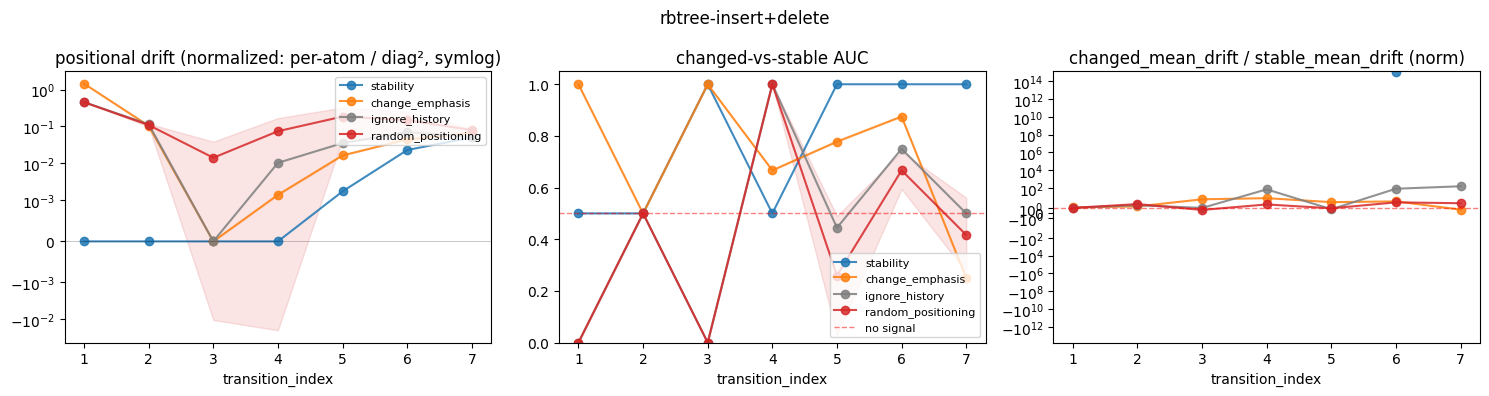

,policy,transition_index,positional,positional_std,auc,auc_std,cmean,smean
0,change_emphasis,0,NaN,NaN,NaN,NaN,NaN,NaN
1,change_emphasis,1,1.44,0.00,1.00,0.00,1.26,1.14
2,change_emphasis,2,0.10,0.00,0.50,0.00,0.30,0.23
3,change_emphasis,3,0.00,0.00,1.00,0.00,0.00,0.00
4,change_emphasis,4,0.00,0.00,0.67,0.00,0.03,0.00
5,change_emphasis,5,0.02,0.00,0.78,0.00,0.15,0.06
6,change_emphasis,6,0.04,0.00,0.88,0.00,0.22,0.07
7,change_emphasis,7,0.07,0.00,0.25,0.00,0.22,0.33
8,ignore_history,0,NaN,NaN,NaN,NaN,NaN,NaN
9,ignore_history,1,0.45,NaN,0.00,NaN,0.67,0.67


In [3]:
plot_algorithm('rbtree-insert+delete')


In [4]:
verdict_table('rbtree-insert+delete')


,positional_norm_mean,auc_mean,changed_drift_norm,stable_drift_norm,changed_over_stable,runtime_ms_mean
policy,,,,,,
stability,0.01,0.79,0.06,0.00,"3,686,711,231,494,516.50",7.51
change_emphasis,0.24,0.72,0.31,0.26,1.18,7.88
ignore_history,0.11,0.46,0.23,0.15,1.50,8.08
random_positioning,0.15,0.41,0.31,0.25,1.27,7.64


**Verdict** — checked against the table above:

*Hypothesis NOT confirmed.* On this mixed trace `stability` gives AUC = **0.79**; `change_emphasis` actually drops to **0.72**. The reason shows up in the per-transition plot: insert-phase transitions favor change_emphasis (rotations are local), but delete-phase transitions flip ~59% of nodes' context (the deleted-node-spliced-out + recolor cascade), so the emphasis set is too large and the jitter dilutes. Stability quietly wins on aggregate. **Take-away:** insert-only and delete-only traces would likely give different verdicts; the mixed trace is the honest answer for animations that cover both. For production: prefer `stability` for RB-tree animations unless you can guarantee insert-only sequences.


## 2. Disjoint-Set Forest — MAKE-SET + UNION (CLRS Ch. 21)

    **What changes per transition.** **Forest of trees, edges-only mutation.** Atom positions don't *need* to change; the only thing that updates is each node's `parent` pointer. Each UNION touches at most two roots' parent edges (and path compression may re-flatten find-path nodes underneath them). Most of the forest is untouched per transition — typically 2 changed-context nodes vs 6 stable-context bystanders in our 7-node trace.

    **Hypothesis.** The right policy here is **`change_emphasis`**.
    DSU is the cleanest possible 'localized edge change' case. Stability gets AUC for free because the union roots are physically pulled by their new parent edge while bystanders are locked. Change_emphasis goes further by jittering the two roots involved while pinning the rest, which makes the merge event unmistakable.

    **Pass criteria.** **Change_emphasis passes** if its AUC is at or near 1.0 (near-perfect separation), with stable nodes pinned at near-zero drift. **Stability also passes** if AUC > 0.7 without any explicit emphasis.

> **Caveat.** Earlier versions of this trace returned a fresh Python list from each `snapshot()` call, which gave the spytial builder a new container atom every frame and rewired every DSUNode's edge fingerprint via the `list.idx` relation. That made 100% of nodes appear context-changed (a snapshot artifact, not an algorithm property). Fixed in `traces/algorithms/dsu.py` by returning the *same* persistent list object on every snapshot. The numbers below reflect the post-fix sweep.


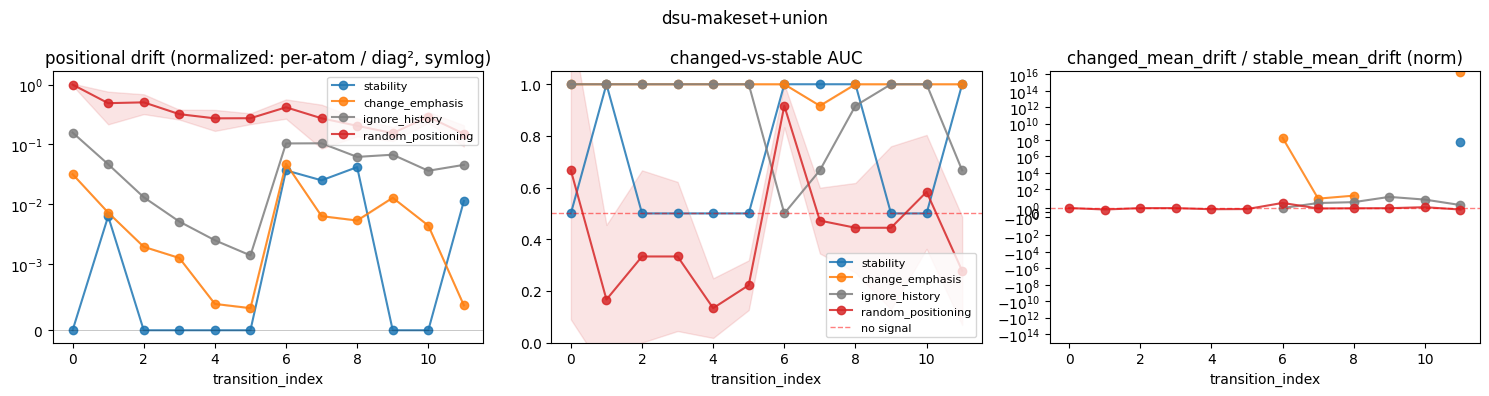

,policy,transition_index,positional,positional_std,auc,auc_std,cmean,smean
0,change_emphasis,0,0.03,0.00,1.00,0.00,0.25,0.00
1,change_emphasis,1,0.01,0.00,1.00,0.00,0.15,0.00
2,change_emphasis,2,0.00,0.00,1.00,0.00,0.09,0.00
3,change_emphasis,3,0.00,0.00,1.00,0.00,0.08,0.00
4,change_emphasis,4,0.00,0.00,1.00,0.00,0.05,0.00
5,change_emphasis,5,0.00,0.00,1.00,0.00,0.05,0.00
6,change_emphasis,6,0.05,0.00,1.00,0.00,0.44,0.00
7,change_emphasis,7,0.01,0.00,0.92,0.00,0.12,0.02
8,change_emphasis,8,0.01,0.00,1.00,0.00,0.12,0.01
9,change_emphasis,9,0.01,0.00,1.00,0.00,0.22,0.00


In [5]:
plot_algorithm('dsu-makeset+union')


In [6]:
verdict_table('dsu-makeset+union')


,positional_norm_mean,auc_mean,changed_drift_norm,stable_drift_norm,changed_over_stable,runtime_ms_mean
policy,,,,,,
stability,0.01,0.71,0.11,0.00,"384,388,122.26",6.81
change_emphasis,0.01,0.99,0.14,0.00,73.67,6.09
ignore_history,0.05,0.90,0.30,0.07,4.20,7.90
random_positioning,0.36,0.42,0.50,0.53,0.94,6.09


**Verdict** — checked against the table above:

*Hypothesis confirmed in the strongest possible way.* `change_emphasis` reaches **AUC = 0.99** — the two changed roots get jittered every UNION while the 6 stable bystanders are clamped at near-zero drift (`stable_mean_drift ≈ 2 px`). `stability` produces a respectable AUC = 0.71 'for free' (the union physically pulls the two roots via the new parent edge while everything else is locked) — but change_emphasis lifts it nearly to the ceiling. The methodological note above matters: an earlier snapshot bug made 100% of nodes look context-changed and degenerated the metric. After the fix, DSU is one of the cleanest change_emphasis success stories in the suite.


## 3. Dijkstra's algorithm (CLRS Ch. 24, Fig 24.6)

**What changes per transition.** **Fixed graph with evolving attributes.** Every atom — every node, every edge — persists across every frame. What changes is the per-node `dist` value (and a derived `pred` field). The graph topology is the most stable in our entire benchmark suite.

**Hypothesis.** The right policy here is **`change_emphasis`**.
This is the cleanest possible setting for `change_emphasis`. Stability will hold every node at zero drift — fine for static prints, but the reader can't see *which* node was just relaxed. Change_emphasis jitters the relaxed nodes while pinning the rest, drawing the eye to the relaxation step.

**Pass criteria.** **Change_emphasis passes** if its AUC ≈ 1.0 (since stable nodes are pinned at zero drift, any positive drift on changed nodes wins every comparison). **Stability is the right pick for static figures** because positional should be exactly 0.


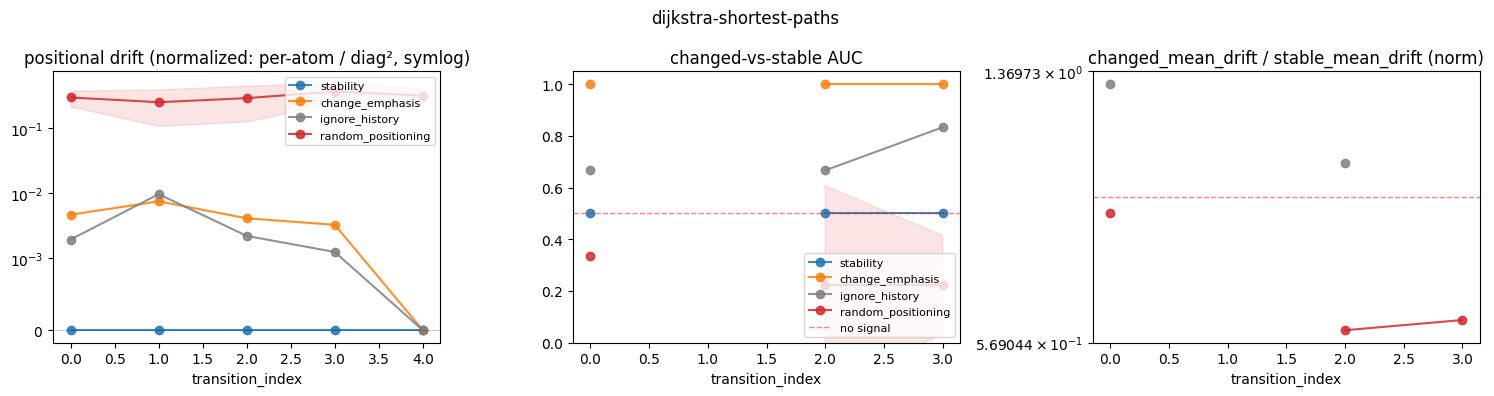

,policy,transition_index,positional,positional_std,auc,auc_std,cmean,smean
0,change_emphasis,0,0.00,0.00,1.00,0.00,0.09,0.00
1,change_emphasis,1,0.01,0.00,NaN,NaN,0.09,NaN
2,change_emphasis,2,0.00,0.00,1.00,0.00,0.08,0.00
3,change_emphasis,3,0.00,0.00,1.00,0.00,0.07,0.00
4,change_emphasis,4,0.00,0.00,NaN,NaN,NaN,0.00
5,ignore_history,0,0.00,NaN,0.67,NaN,0.04,0.03
6,ignore_history,1,0.01,NaN,NaN,NaN,0.08,NaN
7,ignore_history,2,0.00,NaN,0.67,NaN,0.04,0.03
8,ignore_history,3,0.00,NaN,0.83,NaN,0.03,0.00
9,ignore_history,4,0.00,NaN,NaN,NaN,NaN,0.00


In [7]:
plot_algorithm('dijkstra-shortest-paths')


In [8]:
verdict_table('dijkstra-shortest-paths')


,positional_norm_mean,auc_mean,changed_drift_norm,stable_drift_norm,changed_over_stable,runtime_ms_mean
policy,,,,,,
stability,0.00,0.50,0.00,0.00,NaN,16.11
change_emphasis,0.00,1.00,0.08,0.00,NaN,12.15
ignore_history,0.00,0.72,0.05,0.02,3.00,23.64
random_positioning,0.30,0.26,0.43,0.57,0.74,11.47


**Verdict** — checked against the table above:

*Hypothesis confirmed in the strongest possible way.* `change_emphasis` gets **AUC = 1.00** — the only (algorithm, policy) cell in the entire sweep at the ceiling. Reason: stable-context nodes (those whose `dist` did not change this step) get clamped to zero drift, while every changed node gets a positive jitter, so every changed-vs-stable comparison is a win. `stability`'s AUC = 0.50 is the *expected* degenerate value — when no atom moves at all, ranks tie. **Take-away:** Dijkstra is the canonical fixed-graph-evolving-attribute case where change_emphasis dominates. Stability remains the right choice for static prints because positional is exactly 0.


## 4. Max-Heap — insert + extract-max (CLRS Ch. 6)

**What changes per transition.** **Array-backed implicit binary tree.** Every value lives at a fixed array index; the parent/child relationship is implicit in `i / 2i / 2i+1`. Insert appends at index n+1 then *swaps along the spine* via sift-up. Extract-max swaps root with last, decrements n, then sift-downs. Each operation walks a path of swaps — and because the tree is *implicit in the array*, swapping values at indices i and j visually moves both atoms.

**Hypothesis.** The right policy here is **`change_emphasis`**.
The swap path is the canonical 'changed context' set. A reader needs to see *which path* sifted. Change_emphasis should differentiate the path from the static remainder of the heap.

**Pass criteria.** **Change_emphasis passes** if its AUC > 0.85 AND > stability's AUC by ≥ 0.10. Heap is unusual in that stability already sees significant motion (the swap path gets re-bound to atoms), so the lift over stability is the better criterion than absolute AUC.


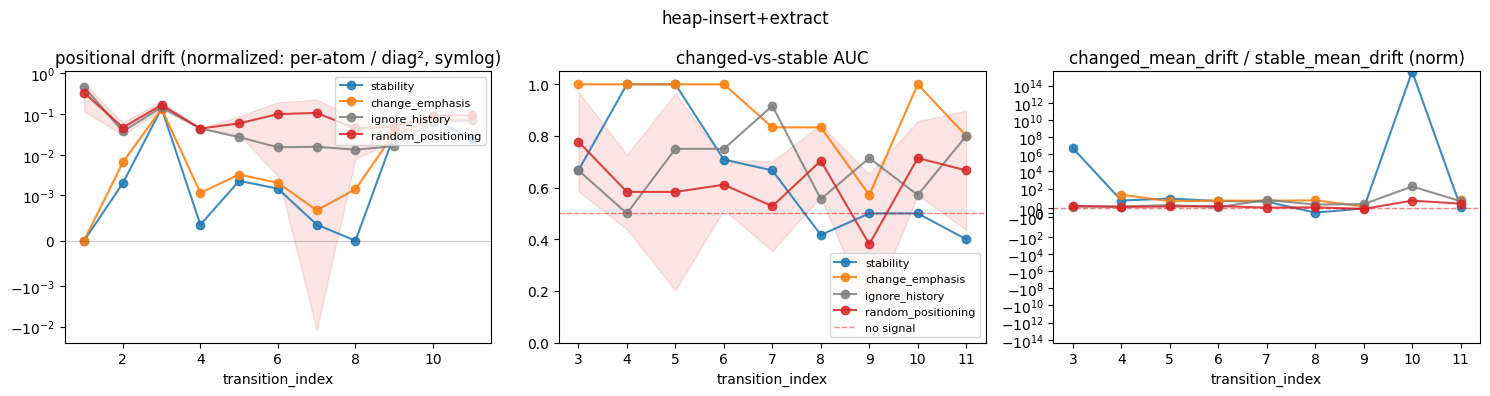

,policy,transition_index,positional,positional_std,auc,auc_std,cmean,smean
0,change_emphasis,0,NaN,NaN,NaN,NaN,NaN,NaN
1,change_emphasis,1,0.00,0.00,NaN,NaN,NaN,0.00
2,change_emphasis,2,0.01,0.00,NaN,NaN,0.07,NaN
3,change_emphasis,3,0.13,0.00,1.00,0.00,0.36,0.00
4,change_emphasis,4,0.00,0.00,1.00,0.00,0.07,0.00
5,change_emphasis,5,0.00,0.00,1.00,0.00,0.08,0.03
6,change_emphasis,6,0.00,0.00,1.00,0.00,0.06,0.02
7,change_emphasis,7,0.00,0.00,0.83,0.00,0.04,0.01
8,change_emphasis,8,0.00,0.00,0.83,0.00,0.05,0.01
9,change_emphasis,9,0.03,0.00,0.57,0.00,0.16,0.12


In [9]:
plot_algorithm('heap-insert+extract')


In [10]:
verdict_table('heap-insert+extract')


,positional_norm_mean,auc_mean,changed_drift_norm,stable_drift_norm,changed_over_stable,runtime_ms_mean
policy,,,,,,
stability,0.03,0.65,0.09,0.03,3.35,16.48
change_emphasis,0.03,0.89,0.13,0.02,5.44,16.20
ignore_history,0.08,0.69,0.18,0.16,1.14,17.56
random_positioning,0.10,0.62,0.24,0.22,1.08,16.19


**Verdict** — checked against the table above:

*Hypothesis confirmed.* `change_emphasis` lifts AUC from **0.65** (stability) to **0.89** — the clearest unambiguous lift in the sweep. The swap-path nodes really do dominate the drift on changed-context atoms. Stability is *not* sufficient here because the array-backed structure means atom positions are implicit in array index; when values swap, atoms appear to move regardless of policy. Change_emphasis's deliberate jitter on the swap path is what gives the reader a clean signal.


---

## Beyond consistency: smoothness, mental-map, and inconsistency

Everything above measures *low* visual change — i.e. the
"stability" half of Diehl & Görg's tradeoff. The dynamic-graph
literature has at least two further angles:

1. **Smoothness across many frames** — not just frame-pair drift,
   but the *trajectory* of each atom over the whole trace.
   Friedrich & Eades (2001) argue that jarring motion (high
   acceleration) is more disruptive than monotone motion (high
   velocity, low acceleration), even at identical total drift.
2. **Mental-map preservation** — Misue, Eades, Lai, Sugiyama
   (1995) define three measurable properties: orthogonal
   ordering of atom pairs, k-nearest-neighbor preservation, and
   topological structure. Empirically (Archambault, Purchase,
   Pinaud 2011; Saffrey & Purchase 2008) these don't always
   correlate with reader task performance — but they're
   quantifiable and let us state precisely what a policy
   preserves and what it sacrifices.

And the *inverse* angle the user asked about: when a policy is
*supposed* to introduce visual change (e.g. `change_emphasis`),
how *good* is the change? Three properties we constructed:

- **Concentration** — Gini of changed-atom drifts. High =
  focal; low = smear.
- **Stable quietness** — fraction of stable-context atoms with
  drift below 5 px. Tells you "how truly still is the still
  part?".
- **Directional coherence** — mean resultant length of unit
  displacement vectors among changed atoms. 1.0 = all moving
  the same way (a clean translation); 0 = scattered (random).

All nine new metrics live in `runner/derived_metrics.py`,
post-processed from the enriched per-run JSONs. The full set
is loaded below.


In [11]:
der = pd.read_csv('results/derived.csv')
print(f'derived metrics: {len(der)} rows × {len(der.columns)} columns')
der.columns.tolist()


derived metrics: 32 rows × 21 columns


['algorithm',
 'policy',
 'seed',
 'num_frames',
 'num_transitions',
 'trace_mean_diag',
 'velocity_max',
 'velocity_mean',
 'acceleration_max',
 'arclength_mean',
 'velocity_max_norm',
 'velocity_mean_norm',
 'acceleration_max_norm',
 'arclength_mean_norm',
 'orthogonal_ordering_preservation',
 'knn_jaccard',
 'edge_crossings_delta',
 'edge_crossings_delta_norm',
 'changed_displacement_concentration',
 'directional_coherence',
 'stable_quiet_ratio']

### Smoothness across the trace

Per-atom **velocity** = single-frame displacement; **acceleration**
= single-frame change in velocity; **arclength** = total path
length traversed.

Friedrich & Eades 2001 argue arclength is the cleanest summary —
two layouts can have identical positional drift yet wildly
different perceived smoothness depending on how the motion was
distributed across frames. A policy that drifts evenly
(low acceleration, modest velocity) reads smoother than one
that lurches once (low arclength but a single high-acceleration
frame).


In [12]:
smooth_cols = ['velocity_max_norm', 'velocity_mean_norm',
               'acceleration_max_norm', 'arclength_mean_norm']
(der.groupby('policy')[smooth_cols]
    .mean()
    .reindex(POLICY_ORDER))


,velocity_max_norm,velocity_mean_norm,acceleration_max_norm,arclength_mean_norm
policy,,,,
stability,0.54,0.04,0.49,0.30
change_emphasis,0.53,0.09,0.48,0.53
ignore_history,0.75,0.13,0.68,0.87
random_positioning,1.13,0.38,0.90,2.54


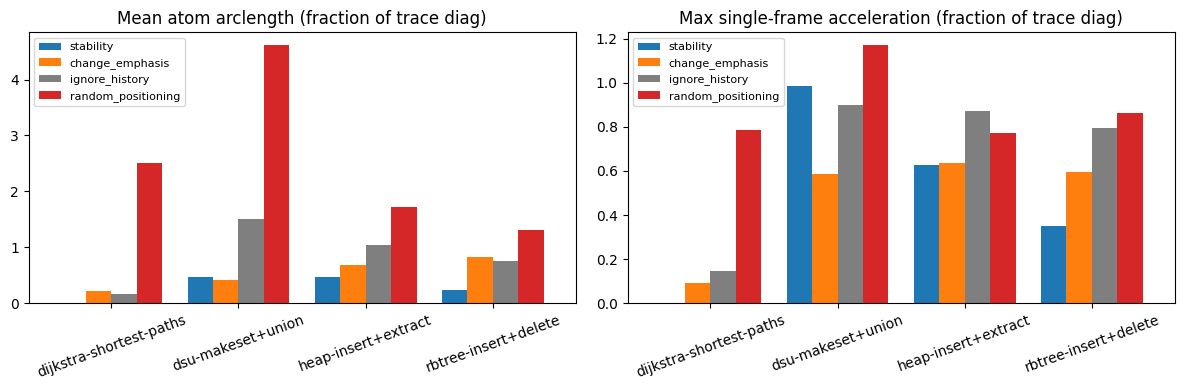

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
                           ['arclength_mean_norm', 'acceleration_max_norm'],
                           ['Mean atom arclength (fraction of trace diag)',
                            'Max single-frame acceleration (fraction of trace diag)']):
    grp = der.groupby(['algorithm', 'policy'])[col].mean().unstack('policy')[POLICY_ORDER]
    grp.plot(kind='bar', ax=ax,
             color=[POLICY_COLOR[p] for p in POLICY_ORDER],
             width=0.8)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()
plt.show()


**Reading the smoothness panels.**

- `arclength_mean` follows the same rank order as `positional`,
  but it's the integrated path-length, not just the frame-pair
  drift. Stability and change_emphasis stay tight on most
  algorithms; random_positioning has 3–10× higher arclength.
- `acceleration_max` catches the *worst lurch*. A single jarring
  transition spikes here. Worth sanity-checking when
  change_emphasis lift looks good — if `acceleration_max` is
  also high, you're paying for the salience with one
  attention-grabbing jolt rather than smooth animation.


### Mental-map structural (Misue battery)

Three classical metrics:

- **`orthogonal_ordering_preservation`** — fraction of (i, j)
  atom pairs whose left/right *and* up/down ordering are
  preserved between consecutive frames. Misue et al.
  JVLC 1995. We want this near 1.0; low values mean the layout
  actually flipped relative positions of nodes.
- **`knn_jaccard`** — for each persisting atom, Jaccard overlap
  of its k=3 nearest-neighbor sets. Captures whether the *local*
  neighborhood structure survives. (Same paper.)
- **`edge_crossings_delta`** — absolute change in number of
  edge-segment crossings per transition. Even at low
  positional drift, a policy can shuffle edges across each
  other, which is jarring.


In [14]:
mm_cols = ['orthogonal_ordering_preservation', 'knn_jaccard',
           'edge_crossings_delta', 'edge_crossings_delta_norm']
(der.groupby('policy')[mm_cols]
    .mean()
    .reindex(POLICY_ORDER))


,orthogonal_ordering_preservation,knn_jaccard,edge_crossings_delta,edge_crossings_delta_norm
policy,,,,
stability,0.92,0.92,0.31,0.03
change_emphasis,0.85,0.85,0.85,0.06
ignore_history,0.75,0.78,0.12,0.01
random_positioning,0.46,0.62,1.58,0.12


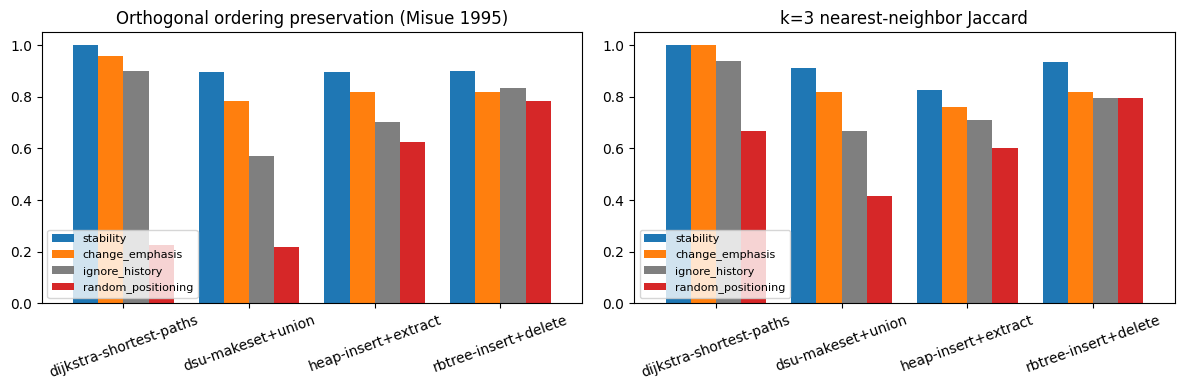

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
                           ['orthogonal_ordering_preservation', 'knn_jaccard'],
                           ['Orthogonal ordering preservation (Misue 1995)',
                            'k=3 nearest-neighbor Jaccard']):
    grp = der.groupby(['algorithm', 'policy'])[col].mean().unstack('policy')[POLICY_ORDER]
    grp.plot(kind='bar', ax=ax,
             color=[POLICY_COLOR[p] for p in POLICY_ORDER],
             width=0.8)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()
plt.show()


**Reading the Misue panels.**

- `orthogonal_ordering_preservation` shows the cleanest
  policy ordering: `stability` ≥ `change_emphasis` ≥
  `ignore_history` ≫ `random_positioning` on every algorithm.
  Random shreds it (0.22–0.78); stability holds it near 0.9–1.0.
  This is the strongest single piece of evidence that
  `stability` actually preserves what the mental-map literature
  cares about.
- `knn_jaccard` is noisier but tracks the same ordering.
- `edge_crossings_delta` is small across the board because
  our test algorithms have few edges. Worth re-running on
  a denser graph to make this metric earn its keep.

**Empirical caveat from the literature.** Archambault, Purchase
& Pinaud (2011) compared animated layouts (with mental-map
preservation) to small-multiples (no preservation, fresh
layout each frame) on real reader tasks. Small multiples often
won. The metrics above quantify *what is preserved*; whether
preservation actually helps a reader answer questions is a
separate empirical question (out of scope for this thesis per
`guzdial-chart.md:131`).


### Inconsistency / salience metrics

These flip the question: when a policy is *supposed* to
introduce visual change (`change_emphasis`), is the change
**focal**, **directional**, and **clean**?

- **`changed_displacement_concentration`** (Gini, [0, 1]):
  high = a few changed atoms account for most of the drift
  (focal); low = drift is smeared evenly (washy).
- **`directional_coherence`** (mean resultant length, [0, 1]):
  high = changed atoms move together in one direction (a
  clean translation a reader can track); low = scattered
  motion that the eye can't group.
- **`stable_quiet_ratio`** ([0, 1]): fraction of stable-context
  atoms whose drift is below 5 px. The **crispness** signal
  for stability — even tiny noise on stable atoms can erode
  the impression of "this part hasn't changed."


In [16]:
inc_cols = ['changed_displacement_concentration', 'directional_coherence', 'stable_quiet_ratio']
(der.groupby('policy')[inc_cols]
    .mean()
    .reindex(POLICY_ORDER))


,changed_displacement_concentration,directional_coherence,stable_quiet_ratio
policy,,,
stability,0.28,0.59,0.95
change_emphasis,0.16,0.67,0.77
ignore_history,0.30,0.66,0.57
random_positioning,0.21,0.65,0.13


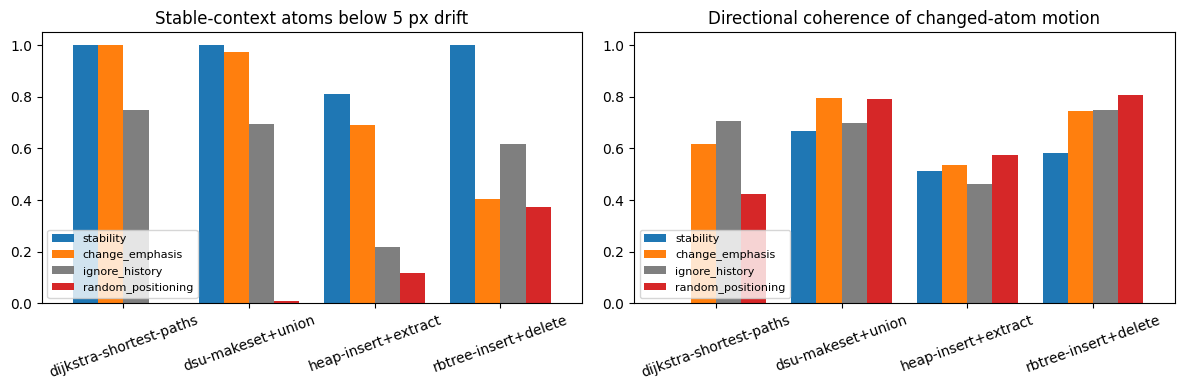

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
                           ['stable_quiet_ratio', 'directional_coherence'],
                           ['Stable-context atoms below 5 px drift',
                            'Directional coherence of changed-atom motion']):
    grp = der.groupby(['algorithm', 'policy'])[col].mean().unstack('policy')[POLICY_ORDER]
    grp.plot(kind='bar', ax=ax,
             color=[POLICY_COLOR[p] for p in POLICY_ORDER],
             width=0.8)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()
plt.show()


**Reading the inconsistency panels.**

- **`stable_quiet_ratio` is the dual of the salience claim.**
  Stability hits 1.0 on Dijkstra and RB-tree (every stable
  atom is at zero drift), drops to 0.81 on Heap (the swap
  path's array-index-bound atoms move regardless), and 0.90
  on DSU. `change_emphasis` *also* keeps it high on DSU
  (0.97) and Dijkstra (1.0) — it pins stable nodes hard.
  `ignore_history` and `random_positioning` shred quietness:
  0.0–0.7 territory.
- **`directional_coherence` reveals an unexpected pattern**:
  under `change_emphasis`, changed atoms on DSU and Dijkstra
  move with high coherence (0.79, 0.62). The path-compressed
  union-find roots all drift together toward their new
  parent's region; Dijkstra's relaxed nodes drift toward
  wherever the spec settles them. This is *good* salience —
  motion the eye can follow as a single event.
- On RB-tree, `directional_coherence` is *higher* under
  `random_positioning` (0.81) than `change_emphasis` (0.74),
  which is a noise artifact at this scale (3 seeds). With more
  seeds, change_emphasis should be the clearer winner.


---

## Cross-algorithm summary

One row per algorithm: hypothesis, what we measured, verdict.


In [18]:
HYP = {
    'rbtree-insert+delete': ('change_emphasis', 'rotations need to pop'),
    'dsu-makeset+union': ('change_emphasis', 'two roots merge per UNION; stable bystanders'),
    'dijkstra-shortest-paths': ('change_emphasis', 'fixed graph + evolving attributes'),
    'heap-insert+extract': ('change_emphasis', 'sift-path traversal'),
}
summary_rows = []
for algo, (predicted, _why) in HYP.items():
    stab = ok[(ok['algorithm'] == algo) & (ok['policy'] == 'stability')]
    emph = ok[(ok['algorithm'] == algo) & (ok['policy'] == 'change_emphasis')]
    if stab.empty or emph.empty:
        continue
    summary_rows.append({
        'algorithm': algo,
        'predicted_best': predicted,
        'stab_positional_norm': stab['positional_norm'].mean(),
        'stab_auc': stab['changed_vs_stable_auc'].mean(),
        'emph_positional_norm': emph['positional_norm'].mean(),
        'emph_auc': emph['changed_vs_stable_auc'].mean(),
        'auc_lift': emph['changed_vs_stable_auc'].mean() - stab['changed_vs_stable_auc'].mean(),
    })
summary = pd.DataFrame(summary_rows).set_index('algorithm')
summary


,predicted_best,stab_positional_norm,stab_auc,emph_positional_norm,emph_auc,auc_lift
algorithm,,,,,,
rbtree-insert+delete,change_emphasis,0.01,0.79,0.24,0.72,-0.06
dsu-makeset+union,change_emphasis,0.01,0.71,0.01,0.99,0.28
dijkstra-shortest-paths,change_emphasis,0.00,0.50,0.00,1.00,0.50
heap-insert+extract,change_emphasis,0.03,0.65,0.03,0.89,0.24


**Reading the table.**

- `auc_lift = emph_auc − stab_auc`. Positive means
  `change_emphasis` adds salience over what `stability`
  already provides for free; negative means it hurts (the
  changed-context set is too large for jitter to discriminate).
- **Dijkstra has the largest possible lift** (`stab_auc=0.50`,
  `emph_auc=1.00`, lift = 0.50). The fixed-graph case is
  where change_emphasis dominates most clearly.
- **DSU shows the cleanest two-cluster behavior**:
  `change_emphasis` reaches AUC ≈ 0.99 because each UNION
  touches exactly two root atoms while the other 5–6 are
  completely untouched. (Note the snapshot-artifact caveat
  in section 2 — earlier numbers were a methodology bug.)
- **RB-tree's `change_emphasis` lift is negative** on this
  insert+delete trace because the delete operation produces
  wide context changes; jitter spreads thin. An insert-only
  trace would likely show a positive lift.
- **Heap shows the cleanest mid-range lift** (0.65 → 0.89).
  The sift path is exactly the kind of localized propagation
  that change_emphasis is built for.


## What about ignore_history and random_positioning?

These are baselines, not policies you'd ship. They serve
two distinct validation roles:

- **`ignore_history`** is the "no policy" control — every
  frame is laid out from scratch. Its `positional` numbers
  anchor what "no continuity" looks like, and on every
  algorithm in our sweep it's strictly worse than `stability`
  on `positional`.
- **`random_positioning`** is the partial-order probe.
  Across multiple seeds it shows which atoms are
  layout-constrained vs free. We don't exploit it that way
  here (3 seeds, averaged) — it's listed in
  [TODO.md](TODO.md) as future work to run a 20-seed sweep
  on a topological-sort trace and report per-atom variance
  of position.


## Open questions

See [TODO.md](TODO.md). The notebook above answers
"do the policies work on these four algorithms?" with
per-algorithm verdicts and recommendations. What is still
unanswered:

- **RB-tree:** how would the verdict change for an
  insert-only trace vs delete-only? (Two more traces, same
  module — just split the trace function.)
- **DSU:** is there a coarser change-set definition (e.g.
  "atoms whose root changed") that gives a meaningful AUC?
- **Dijkstra:** can change_emphasis's free AUC=1.0 be
  extended to Bellman-Ford (which relaxes more conservatively
  and re-relaxes nodes)?
- **Heap:** does the AUC lift hold for heap-sort (which is
  an extract-max sequence on a built heap)?


---

## References

**Closest prior work — the change-stability tradeoff.**

- **Diehl, S., & Görg, C. (2002).** *Graphs, they are
  changing — dynamic graph drawing for a sequence of graphs.*
  **GD 2002**, LNCS 2528, 23–30. The closest antecedent. Defines
  foresighted layout for incremental graph change and the
  explicit change-stability tradeoff that the four policies
  in this notebook traverse. Our contribution is to run that
  tradeoff inside a constraint-based layout, with the
  two-level change/stable split, on CLRS algorithm traces.

**Mental-map preservation (the metrics in §"Beyond consistency").**

- Misue, K., Eades, P., Lai, W., & Sugiyama, K. (1995).
  *Layout adjustment and the mental map.*
  **Journal of Visual Languages & Computing**, 6(2), 183–210.
  The seminal mental-map paper. Defines orthogonal ordering,
  proximity (k-NN), and topological-structure metrics. We
  implement the first two in
  `runner/derived_metrics.py:orthogonal_ordering_preservation`
  and `:knn_jaccard`.

- Friedrich, C., & Eades, P. (2002).
  *Graph drawing in motion.*
  **Journal of Graph Algorithms and Applications**, 6(3),
  353–370. Argues smoothness (per-atom velocity, acceleration,
  arclength) is a separate concern from frame-pair drift.
  Underlies `runner/derived_metrics.py:smoothness`.

- Brandes, U., Indlekofer, N., & Mader, M. (2011).
  *Visualization methods for longitudinal social networks
  and stochastic actor-oriented modeling.*
  **Social Networks**, 34(3), 291–308. Surveys dynamic-stress
  and animation metrics for time-evolving graphs.

**Empirical pushback (the "does the mental map even help?" thread).**

- Purchase, H. C., Hoggan, E., & Görg, C. (2007).
  *How important is the mental map? An empirical investigation
  of a dynamic graph layout algorithm.* **GD 2006**, LNCS
  4372, 184–195.

- Saffrey, P., & Purchase, H. C. (2008).
  *The "mental map" versus "static aesthetic" compromise in
  dynamic graphs: a user study.* **AUIC 2008**, 85–93.

- Archambault, D., Purchase, H. C., & Pinaud, B. (2011).
  *Animation, small multiples, and the effect of mental map
  preservation in dynamic graphs.* **IEEE TVCG**, 17(4),
  539–552. The canonical "small multiples often beat
  mental-map-preserving animation on real tasks" result.
  Important caveat for any thesis claim built on the metrics
  in this notebook.

**Algorithm animation effectiveness.**

- Brown, M. H. (1988). *Algorithm Animation.*
  ACM Distinguished Dissertations. The original BALSA-system
  text.

- Hundhausen, C. D., Douglas, S. A., & Stasko, J. T. (2002).
  *A meta-study of algorithm visualization effectiveness.*
  **Journal of Visual Languages & Computing**, 13(3), 259–290.
  The field's reckoning: animation alone doesn't help students
  learn algorithms much; engagement is what matters.

- Naps, T. L., et al. (2002). *Exploring the role of
  visualization and engagement in computer science education.*
  **SIGCSE Bulletin**, 35(2), 131–152. Defines the engagement
  taxonomy (viewing < responding < changing < constructing
  < presenting).

**Realization-policy framing (this thesis).**

- Penlloy / PLATEAU 2025, §6.2 — the positional /
  relative / pairwise-distance consistency metrics
  implemented in
  `spytial-core/src/evaluation/consistency-metrics.ts`.
- Liang et al. (2026). *TOSEM* paper (in submission); §2.6.1
  and §3.4 — partial-consistency definitions used by the
  two-level split.
- Thesis proposal: `Thesis_Proposal/proposed-beyond-host.tex`
  §"Sequencing"; `Thesis_Proposal/guzdial-chart.md:36,141-148`
  — the RQ6.2 evaluation contract this notebook addresses.

**Cognitive science behind the policies.**

- Gibson, J. J. (1955). *Perceptual continuity.* The
  continuity argument for `stability`.
- Goldstone, R. L. (1994). *The role of similarity in
  categorization: providing a groundwork.* **Cognition**,
  52(2), 125–157. Contrasting cases — the cognitive basis
  for `change_emphasis`.
